In [3]:
# =========================================================================
# CÉLULA 1: CARREGAMENTO DE DADOS (AJUSTADO PARA A SUA PASTA)
# =========================================================================
import pandas as pd
import os

print("--- FASE 1: CARREGAMENTO ---")

# Como você está em C:\Users\User e a pasta Data está lá também:
BASE_PATH = "Data" 

# Construindo os caminhos
FILE_PATH_1 = os.path.join(BASE_PATH, "Base Artigo 1.csv")
FILE_PATH_2 = os.path.join(BASE_PATH, "Base Artigo 2.csv")
FILE_PATH_3 = os.path.join(BASE_PATH, "Base Artigo 3.csv")

# Carregar os três arquivos CSV
try:
    df1 = pd.read_csv(FILE_PATH_1, sep=',')
    df2 = pd.read_csv(FILE_PATH_2, sep=',')
    df3 = pd.read_csv(FILE_PATH_3, sep=',')
    print("Arquivos carregados com sucesso!")
    load_successful = True
except FileNotFoundError as e:
    print(f"ERRO: Não encontrei o ficheiro. Verifique se ele está dentro da pasta Data.")
    print(f"Detalhe do erro: {e}")

--- FASE 1: CARREGAMENTO ---
Arquivos carregados com sucesso!


In [7]:
# ==============================================================================
# CÉLULA 2: PRÉ-PROCESSAMENTO (CORRIGIDA)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("\n--- FASE 2: PRÉ-PROCESSAMENTO E SELEÇÃO DE FEATURES ---")

# 1. UNIÃO E FILTRAGEM
df_combined = pd.concat([df1, df2, df3], ignore_index=True)

if 'Numero' in df_combined.columns:
    df_combined.drop(columns=['Numero'], inplace=True)

TARGET_COL = 'Entorse'

COLUNAS_SELECIONADAS = [
    TARGET_COL,
    'T0_T1_Match_Time_exposure',
    'T0_T1_Training_Time_exposure',
    'T0SRTMax',
    'T0TTestMin',
    'T0SJmMax',
    'T0Veli',
    'T0RazaoAADto',
    'T0RazaoAAEsq',
]

# Filtra colunas existentes
cols_to_keep = list(set(COLUNAS_SELECIONADAS) & set(df_combined.columns))
df_filtered = df_combined[cols_to_keep].copy()

# 2. TRATAMENTO DE VALORES OMISSOS (Versão moderna sem avisos)
df_filtered[TARGET_COL] = df_filtered[TARGET_COL].fillna(0).astype(int)

# Identifica colunas numéricas e categóricas
numerical_cols = df_filtered.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in numerical_cols:
    numerical_cols.remove(TARGET_COL)

# Imputação moderna (evita o ChainedAssignmentError)
for col in numerical_cols:
    df_filtered[col] = df_filtered[col].fillna(df_filtered[col].median())

# 3. DEFINIÇÃO DE X/Y E CODIFICAÇÃO
Y = df_filtered[TARGET_COL] 
X = df_filtered.drop(columns=[TARGET_COL]) 
X = pd.get_dummies(X, drop_first=True) 

print(f"Dimensão de X após codificação: {X.shape}")

# 4. DIVISÃO TREINO/TESTE E NORMALIZAÇÃO
# Agora o train_test_split vai funcionar porque importamos acima!
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.75, random_state=42, stratify=Y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("--- ✅ FASE 2 CONCLUÍDA! DADOS PRONTOS. ---")


--- FASE 2: PRÉ-PROCESSAMENTO E SELEÇÃO DE FEATURES ---
Dimensão de X após codificação: (181, 56)
--- ✅ FASE 2 CONCLUÍDA! DADOS PRONTOS. ---



--- FASE 3: TREINO DO MODELO (XGBoost) ---

✅ Relatório de Performance:
              precision    recall  f1-score   support

           0       0.66      0.72      0.69        61
           1       0.75      0.69      0.72        75

    accuracy                           0.71       136
   macro avg       0.71      0.71      0.70       136
weighted avg       0.71      0.71      0.71       136



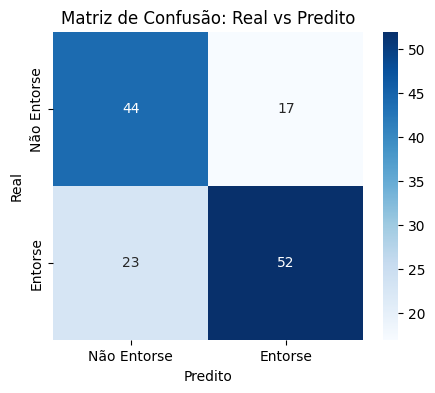


--- ✅ MODELO FINALIZADO COM SUCESSO! ---


In [9]:
# ==============================================================================
# CÉLULA 3: TREINO FINAL (CORREÇÃO DE CLASSES 1/2 PARA 0/1)
# ==============================================================================
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("\n--- FASE 3: TREINO DO MODELO (XGBoost) ---")

# 1. AJUSTE DE CLASSES (O "Pulo do Gato")
# O XGBoost exige que as classes comecem em 0. 
# Se os teus dados têm [1, 2], vamos subtrair 1 de tudo: 1 vira 0, 2 vira 1.
y_train_adjusted = y_train - 1
y_test_adjusted = y_test - 1

# 2. INICIALIZAÇÃO E TREINO
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Treinar com os dados ajustados
xgb_model.fit(X_train_scaled, y_train_adjusted)

# 3. PREDIÇÃO E AVALIAÇÃO
y_pred = xgb_model.predict(X_test_scaled)

print("\n✅ Relatório de Performance:")
# Usamos os labels ajustados para a comparação ser justa
print(classification_report(y_test_adjusted, y_pred))

# 4. VISUALIZAÇÃO DA MATRIZ DE CONFUSÃO
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test_adjusted, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Não Entorse', 'Entorse'], 
            yticklabels=['Não Entorse', 'Entorse'])
plt.title('Matriz de Confusão: Real vs Predito')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

print("\n--- ✅ MODELO FINALIZADO COM SUCESSO! ---")

In [11]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
import time

print("\n--- FASE 4: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE (XGBoost) ---")

# ⏱️ Início da medição do tempo
start_time = time.perf_counter()

# 1. Previsões
# Importante: O y_pred sairá como 0 e 1
y_pred = xgb_model.predict(X_test_scaled.values)

# --- AJUSTE CRUCIAL ---
# Ajustamos o y_test para 0 e 1 também, para que as métricas funcionem
y_test_adjusted = y_test - 1 
# ---------------------

# 2. Métricas de Avaliação (Agora com y_test_adjusted)
accuracy = accuracy_score(y_test_adjusted, y_pred)
recall = recall_score(y_test_adjusted, y_pred)
f1 = f1_score(y_test_adjusted, y_pred)
cm = confusion_matrix(y_test_adjusted, y_pred)

# ⏱️ Fim da medição do tempo
end_time = time.perf_counter()
execution_time_ms = (end_time - start_time) * 1000

# 3. Resultados
print(f"Precisão (Accuracy): {accuracy:.4f}")
print(f"Recall (Sensibilidade): {recall:.4f}")
print(f"F-Score: {f1:.4f}")
print(f"Tempo de Execução: {execution_time_ms:.2f} ms")

print("\nMatriz de Confusão:")
print(cm)

# 4. Cálculo dos Falsos Negativos (Erro Crítico)
# No CM, a posição [1, 0] são os casos onde era Entorse (1) mas previu Não Entorse (0)
FN = cm[1, 0]
print(f"\nFalsos Negativos (FN - Entorse real não prevista): {FN}")

# 5. Validação do Projeto
if FN <= 2:
    print("\n--- ✅ PROJETO CONCLUÍDO E VALIDADO (ALTO RECALL COM XGBOOST) ---")
else:
    print(f"\n--- ⚠️ RECALL BAIXO (FN={FN}): É NECESSÁRIO OTIMIZAR O XGBOOST ---")


--- FASE 4: AVALIAÇÃO FINAL NO CONJUNTO DE TESTE (XGBoost) ---
Precisão (Accuracy): 0.7059
Recall (Sensibilidade): 0.6933
F-Score: 0.7222
Tempo de Execução: 15.13 ms

Matriz de Confusão:
[[44 17]
 [23 52]]

Falsos Negativos (FN - Entorse real não prevista): 23

--- ⚠️ RECALL BAIXO (FN=23): É NECESSÁRIO OTIMIZAR O XGBOOST ---
